# Simple self-created spelled-out Neural Network
## Test: Training it on a couple of simple linear equations for it to try and learn the coefficients

#### Imports

In [1]:
import random
from engine import Data 
from nn import MLP
from show import Show

In [2]:
random.seed(42)

#### Creating dataset (params/ groundtruth)

In [3]:
def make_data(n=20):
    X = []
    Y = []
    for _ in range(n):
        x1 = random.uniform(-2, 2)
        x2 = random.uniform(-2, 2)
        y = 2 * x1 - 3 * x2 + 0.5
        X.append([Data(x1), Data(x2)])
        Y.append(Data(y))
    return X, Y

In [4]:
X,Y = make_data(50)
mlp = MLP(2, [1])
epochs = 5000
lr = 0.001

#### Training

In [5]:
for epoch in range(epochs):
    for p in mlp.params():
        p.grad = 0.0
    
    total_loss = 0
    for x, y_in in zip(X, Y):
        y_out = mlp(x)
        loss = (y_out - y_in)**2
        total_loss += loss
        
    total_loss.backprop()
    

    for p in mlp.params():
        p.data -= lr * (p.grad / len(X))

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss.data / len(X):.4f}")

Epoch 0 | Loss: 23.6560
Epoch 100 | Loss: 14.7676
Epoch 200 | Loss: 9.3069
Epoch 300 | Loss: 5.9259
Epoch 400 | Loss: 3.8144
Epoch 500 | Loss: 2.4833
Epoch 600 | Loss: 1.6357
Epoch 700 | Loss: 1.0901
Epoch 800 | Loss: 0.7348
Epoch 900 | Loss: 0.5009
Epoch 1000 | Loss: 0.3450
Epoch 1100 | Loss: 0.2399
Epoch 1200 | Loss: 0.1683
Epoch 1300 | Loss: 0.1190
Epoch 1400 | Loss: 0.0847
Epoch 1500 | Loss: 0.0606
Epoch 1600 | Loss: 0.0436
Epoch 1700 | Loss: 0.0315
Epoch 1800 | Loss: 0.0229
Epoch 1900 | Loss: 0.0167
Epoch 2000 | Loss: 0.0121
Epoch 2100 | Loss: 0.0089
Epoch 2200 | Loss: 0.0065
Epoch 2300 | Loss: 0.0048
Epoch 2400 | Loss: 0.0035
Epoch 2500 | Loss: 0.0026
Epoch 2600 | Loss: 0.0019
Epoch 2700 | Loss: 0.0014
Epoch 2800 | Loss: 0.0010
Epoch 2900 | Loss: 0.0008
Epoch 3000 | Loss: 0.0006
Epoch 3100 | Loss: 0.0004
Epoch 3200 | Loss: 0.0003
Epoch 3300 | Loss: 0.0002
Epoch 3400 | Loss: 0.0002
Epoch 3500 | Loss: 0.0001
Epoch 3600 | Loss: 0.0001
Epoch 3700 | Loss: 0.0001
Epoch 3800 | Loss: 0.0

#### Checking on the training, see the output

In [6]:
test_x = [Data(1), Data(3)] 
pred_y = mlp(test_x)
print(f"Expected: -6.5 | Predicted: {pred_y.data:.2f}")

Expected: -6.5 | Predicted: -6.50


In [7]:
last_neuron = mlp.layers[0].neurons[0]
print(f"Learned w1: {last_neuron.weights[0].data:.4f} (Expected: 2.0)")
print(f"Learned w2: {last_neuron.weights[1].data:.4f} (Expected: -3.0)")
print(f"Learned b:  {last_neuron.bias.data:.4f} (Expected: 0.5)")

Learned w1: 1.9996 (Expected: 2.0)
Learned w2: -2.9992 (Expected: -3.0)
Learned b:  0.5010 (Expected: 0.5)


#### Visualising the whole graph

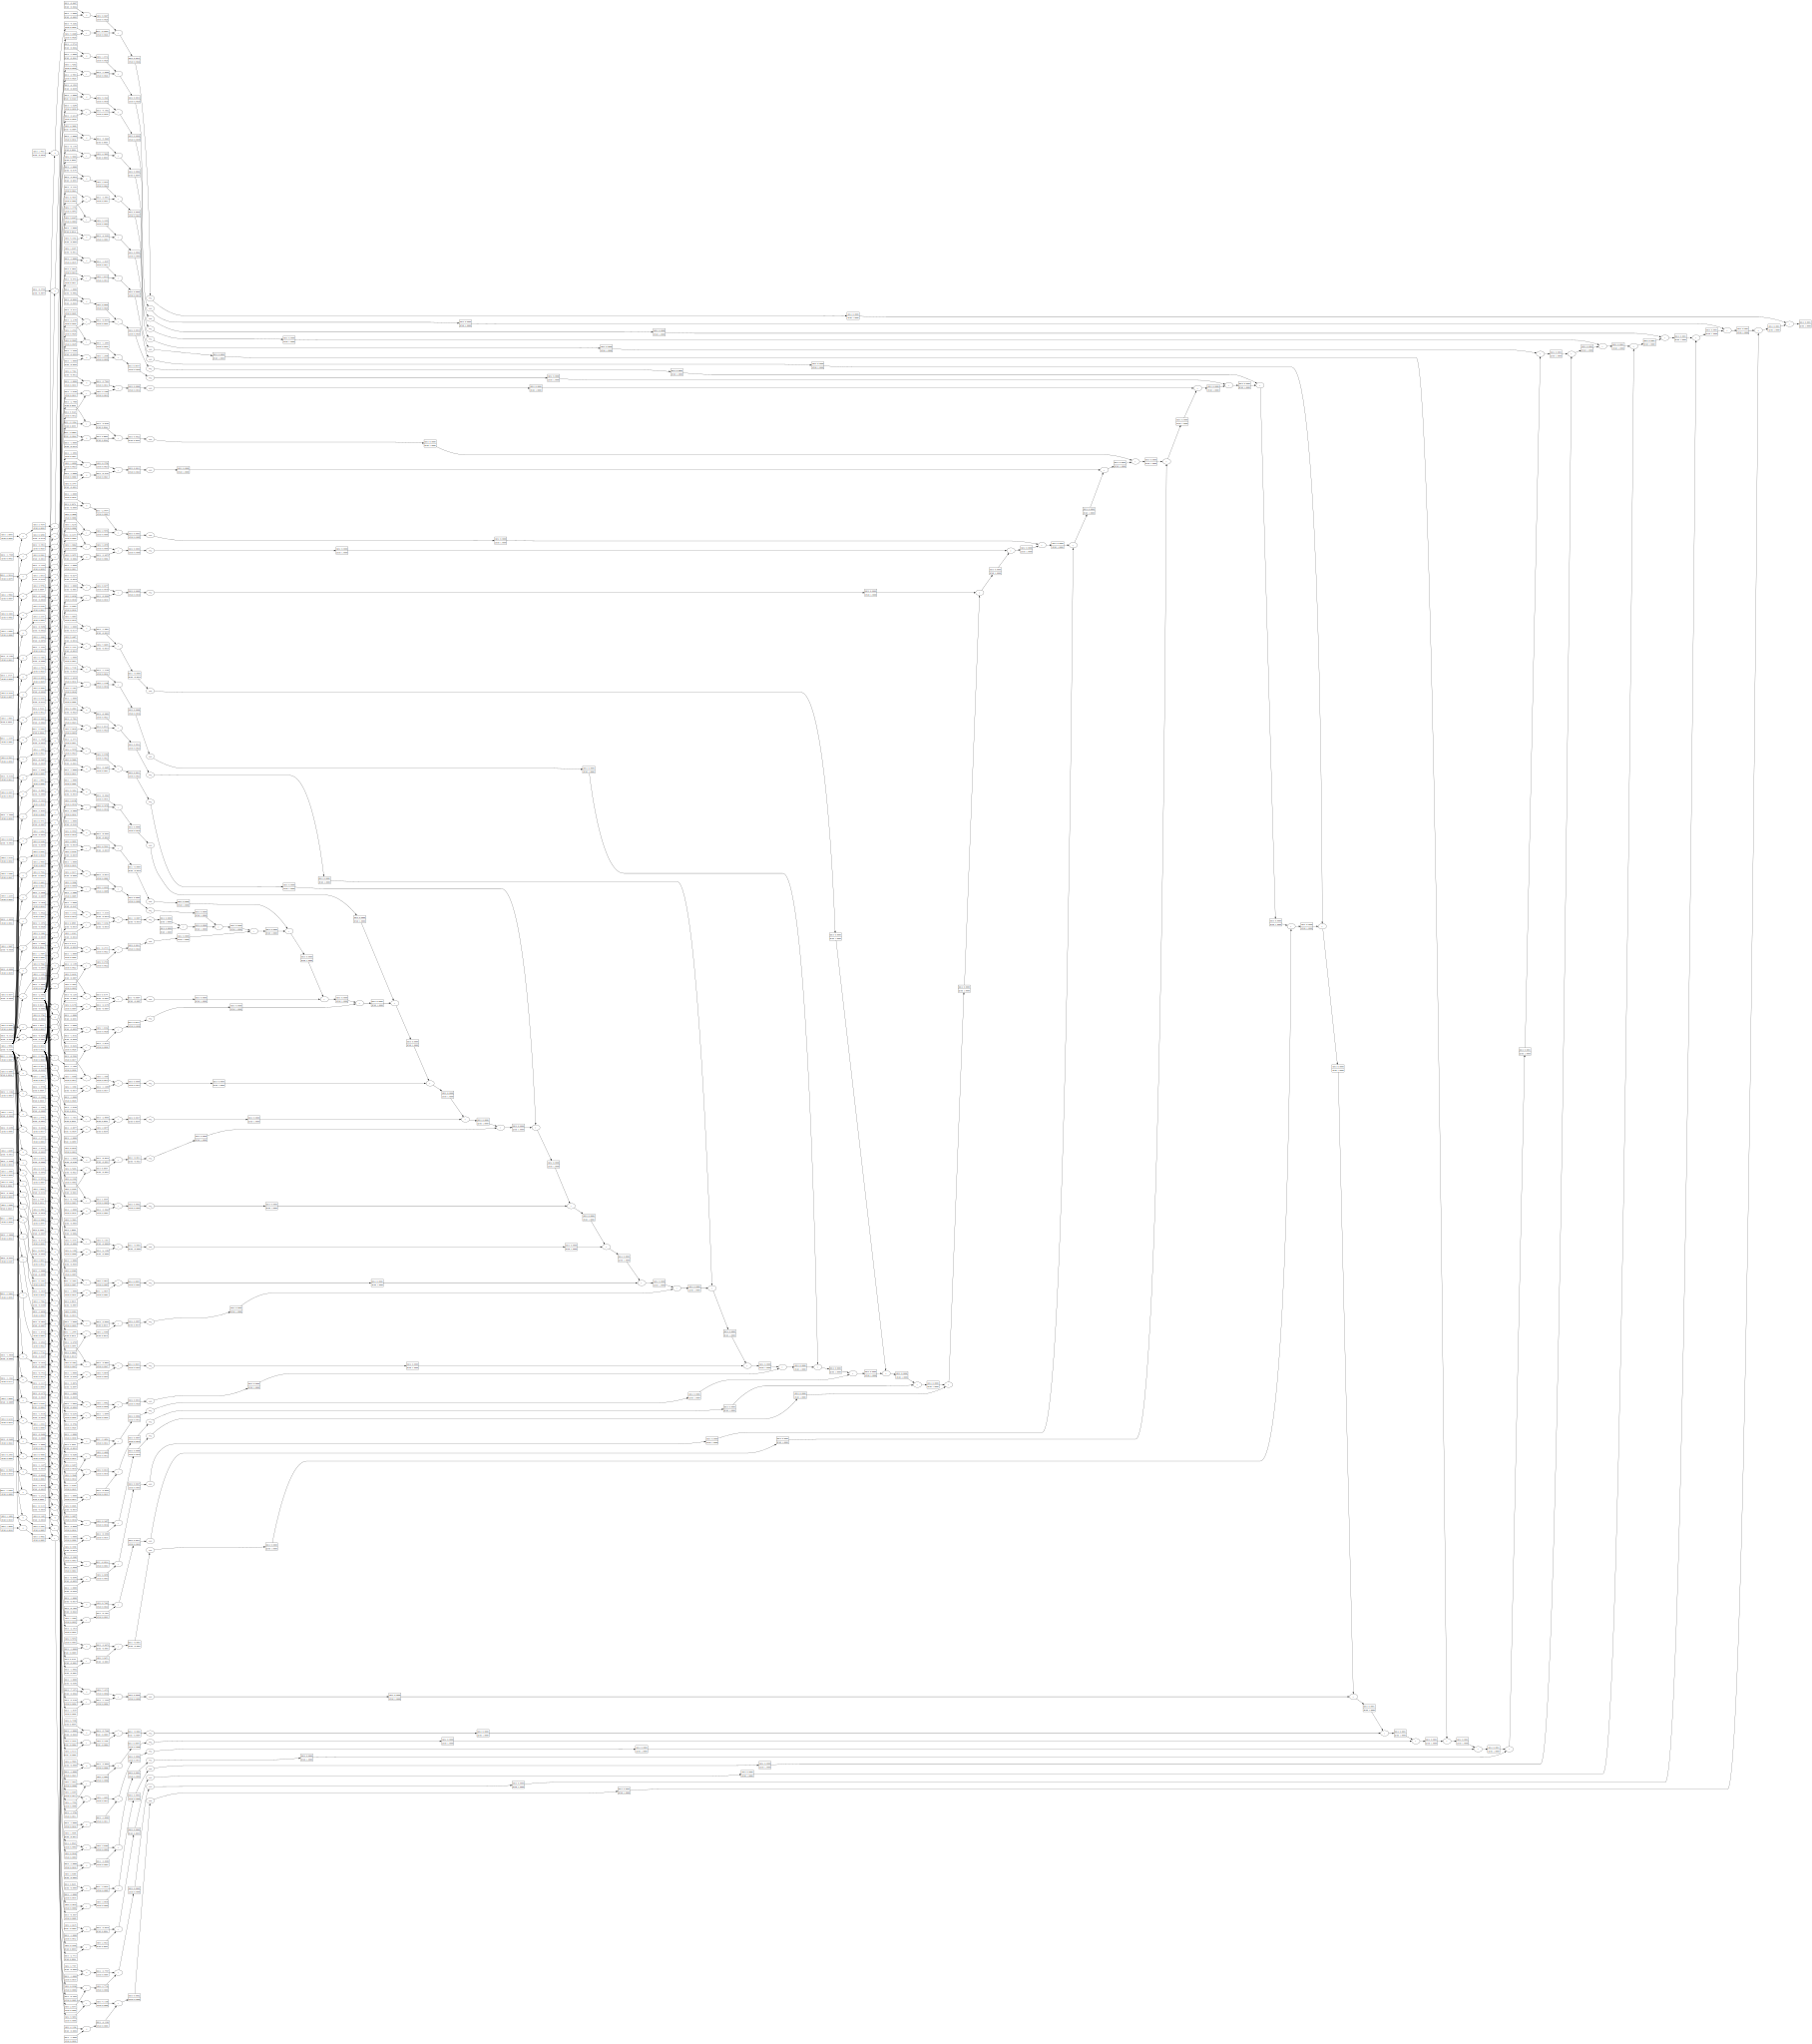

In [8]:
show = Show(total_loss)
show.show()